# 📊 Modelagem de Regressão - Desafio 2

**Ciência e Governança de Dados - Zetta Lab**

---

## 🎯 Objetivo

Prever as taxas de **abandono escolar** e **repetência** no Ensino Fundamental e Médio brasileiro usando indicadores socioeconômicos.

## 📋 Metodologia CRISP-DM

Este notebook implementa a **Fase 4: Modelagem** do CRISP-DM, focando em:
- Construção de modelos de regressão
- Comparação de algoritmos (Linear Regression, Random Forest, XGBoost)
- Avaliação de performance
- Interpretação dos resultados

## 📊 Dataset

- **Fonte**: Dados consolidados de INEP, IBGE SIDRA e Atlas Brasil
- **Granularidade**: 27 Unidades Federativas (UFs)
- **Período**: 2018-2022 (135 registros)
- **Variáveis**:
  - **Targets**: Taxa_Abandono_Media, Taxa_Reprovacao_Media
  - **Preditores**: IDHM, Taxa_Desemprego, Renda_Per_Capita, Indice_Gini, Taxa_Gravidez_Adolescente, PIB_Total_MilReais

## 🛠️ Estratégia de Validação

- **Treino**: Dados de 2018-2021 (108 registros)
- **Teste**: Dados de 2022 (27 registros)
- **Métricas**: MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), R² (Coeficiente de Determinação)

## 📚 Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 📥 Carregamento dos Dados

Carregamos o dataset final consolidado após a fase de preparação dos dados.

In [2]:
df = pd.read_csv('../data/Processed/dados_modelo_final.csv')
print(f"Dataset carregado: {len(df)} registros, {len(df.columns)} variáveis")
print("\nColunas disponíveis:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Dataset carregado: 135 registros, 17 variáveis

Colunas disponíveis:
 1. UF
 2. Ano
 3. Taxa_Abandono_Media
 4. Taxa_Abandono_EF
 5. Taxa_Abandono_EM
 6. Taxa_Reprovacao_Media
 7. Taxa_Reprovacao_EF
 8. Taxa_Reprovacao_EM
 9. IDHM
10. Taxa_Desemprego
11. Renda_Per_Capita
12. Indice_Gini_x
13. Taxa_Gravidez_Adolescente_x
14. PIB_Total_MilReais_x
15. Indice_Gini_y
16. Taxa_Gravidez_Adolescente_y
17. PIB_Total_MilReais_y


## 🔍 Seleção de Features e Target

### Variáveis Selecionadas

**Target Principal**: Taxa_Abandono_Media (taxa média de abandono no Ensino Fundamental e Médio)

**Features Socioeconômicas**:
- **Ano**: Controle temporal para capturar tendências
- **IDHM**: Índice de Desenvolvimento Humano Municipal
- **Taxa_Desemprego**: Percentual da população economicamente ativa desempregada
- **Renda_Per_Capita**: Renda média per capita da população
- **Indice_Gini**: Medida de desigualdade de renda (0 = igualdade perfeita, 1 = desigualdade máxima)
- **Taxa_Gravidez_Adolescente**: Percentual de gestações na faixa etária 10-19 anos
- **PIB_Total_MilReais**: Produto Interno Bruto total em milhões de reais

In [4]:
features = [
    'Ano', 'IDHM', 'Taxa_Desemprego', 'Renda_Per_Capita',
    'Indice_Gini_x', 'Taxa_Gravidez_Adolescente_x', 'PIB_Total_MilReais_x'
]

X = df[features].copy()
y_abandono = df['Taxa_Abandono_Media'].copy()
y_repetencia = df['Taxa_Reprovacao_Media'].copy()

print(f"Features selecionadas ({len(features)}):")
for i, feat in enumerate(features, 1):
    print(f"  {i}. {feat}")
    
print(f"\nTarget - Abandono: {y_abandono.name}")
print(f"Target - Repetência: {y_repetencia.name}")

Features selecionadas (7):
  1. Ano
  2. IDHM
  3. Taxa_Desemprego
  4. Renda_Per_Capita
  5. Indice_Gini_x
  6. Taxa_Gravidez_Adolescente_x
  7. PIB_Total_MilReais_x

Target - Abandono: Taxa_Abandono_Media
Target - Repetência: Taxa_Reprovacao_Media


## 📊 Análise Exploratória dos Dados

### Estatísticas Descritivas

Analisamos as características estatísticas das variáveis preditoras para entender a distribuição dos dados.

In [6]:
print("Estatísticas Descritivas das Features:")
desc_stats = X.describe().round(2)
desc_stats

Estatísticas Descritivas das Features:


,Ano,IDHM,Taxa_Desemprego,Renda_Per_Capita,Indice_Gini_x,Taxa_Gravidez_Adolescente_x,PIB_Total_MilReais_x
count,135.00,135.00,135.00,135.00,135.00,135.00,1.350000e+02
mean,2020.00,0.74,11.33,1216.19,0.51,15.59,3.044051e+08
std,1.42,0.04,3.89,436.70,0.04,4.04,4.999939e+08
min,2018.00,0.68,3.10,586.00,0.41,7.91,1.336999e+07
25%,2019.00,0.71,8.50,869.00,0.48,12.52,6.108304e+07
50%,2020.00,0.74,11.20,1072.00,0.52,15.55,1.422038e+08
75%,2021.00,0.77,14.20,1492.00,0.55,18.50,3.017740e+08
max,2022.00,0.86,20.70,2802.00,0.60,24.22,3.130333e+09


### Correlação entre Variáveis

Analisamos as correlações lineares entre as features e os targets para identificar relações potenciais.

**Interpretação**:
- Correlações positivas: variáveis que crescem juntas
- Correlações negativas: variáveis inversamente relacionadas
- Valores próximos de ±1 indicam forte relação linear
- Valores próximos de 0 indicam pouca ou nenhuma relação linear

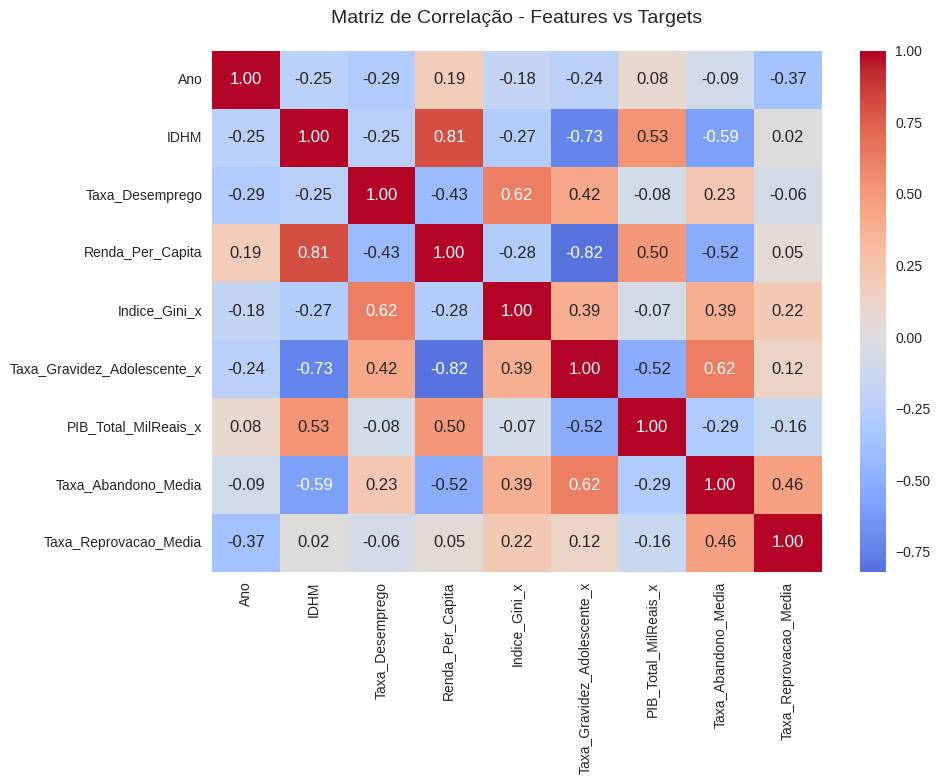

In [7]:
corr_matrix = pd.concat([X, y_abandono, y_repetencia], axis=1).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação - Features vs Targets', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [8]:
print("Correlações com Taxa de Abandono:")
corr_abandono = corr_matrix['Taxa_Abandono_Media'].sort_values(ascending=False)
print(corr_abandono.round(3))

print("\nCorrelações com Taxa de Repetência:")
corr_repetencia = corr_matrix['Taxa_Reprovacao_Media'].sort_values(ascending=False)
print(corr_repetencia.round(3))

Correlações com Taxa de Abandono:
Taxa_Abandono_Media            1.000
Taxa_Gravidez_Adolescente_x    0.622
Taxa_Reprovacao_Media          0.463
Indice_Gini_x                  0.388
Taxa_Desemprego                0.230
Ano                           -0.092
PIB_Total_MilReais_x          -0.292
Renda_Per_Capita              -0.520
IDHM                          -0.592
Name: Taxa_Abandono_Media, dtype: float64

Correlações com Taxa de Repetência:
Taxa_Reprovacao_Media          1.000
Taxa_Abandono_Media            0.463
Indice_Gini_x                  0.216
Taxa_Gravidez_Adolescente_x    0.124
Renda_Per_Capita               0.047
IDHM                           0.016
Taxa_Desemprego               -0.064
PIB_Total_MilReais_x          -0.155
Ano                           -0.367
Name: Taxa_Reprovacao_Media, dtype: float64


## ✂️ Divisão Treino/Teste

### Estratégia Temporal

Usamos uma abordagem de **validação temporal** para simular cenários reais de previsão:

- **Conjunto de Treino**: Dados históricos (2018-2021)
- **Conjunto de Teste**: Dados mais recentes (2022)

Esta estratégia avalia a capacidade do modelo de generalizar para períodos futuros, o que é crucial para aplicações práticas em educação.

In [9]:
train_mask = df['Ano'] <= 2021
test_mask = df['Ano'] == 2022

X_train, X_test = X[train_mask], X[test_mask]
y_abandono_train, y_abandono_test = y_abandono[train_mask], y_abandono[test_mask]
y_repetencia_train, y_repetencia_test = y_repetencia[train_mask], y_repetencia[test_mask]

print(f"Conjunto de Treino: {len(X_train)} registros (2018-2021)")
print(f"Conjunto de Teste: {len(X_test)} registros (2022)")
print(f"Proporção Treino/Teste: {len(X_train)/len(X):.1%} / {len(X_test)/len(X):.1%}")

Conjunto de Treino: 108 registros (2018-2021)
Conjunto de Teste: 27 registros (2022)
Proporção Treino/Teste: 80.0% / 20.0%


## 🤖 Modelagem - Regressão Linear (Baseline)

### Por que começar com Regressão Linear?

A regressão linear serve como **baseline** porque:
- É o modelo mais simples e interpretável
- Estabelece uma referência de performance mínima
- Permite verificar se há relação linear entre features e target
- Os coeficientes indicam a direção e magnitude da influência de cada variável

In [10]:
lr_abandono = LinearRegression()
lr_abandono.fit(X_train, y_abandono_train)
y_abandono_pred_lr = lr_abandono.predict(X_test)

lr_repetencia = LinearRegression()
lr_repetencia.fit(X_train, y_repetencia_train)
y_repetencia_pred_lr = lr_repetencia.predict(X_test)

In [11]:
def calcular_metricas(y_true, y_pred, nome_modelo, nome_target):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{nome_modelo} - {nome_target}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

metricas_lr_abandono = calcular_metricas(y_abandono_test, y_abandono_pred_lr, "Regressão Linear", "Taxa de Abandono")
metricas_lr_repetencia = calcular_metricas(y_repetencia_test, y_repetencia_pred_lr, "Regressão Linear", "Taxa de Repetência")


Regressão Linear - Taxa de Abandono:
  MAE:  0.8037
  RMSE: 1.0726
  R²:   0.1802

Regressão Linear - Taxa de Repetência:
  MAE:  4.3360
  RMSE: 5.0256
  R²:   -2.9081


### Interpretação dos Coeficientes

Analisamos os coeficientes da regressão linear para entender a influência de cada variável na taxa de abandono.

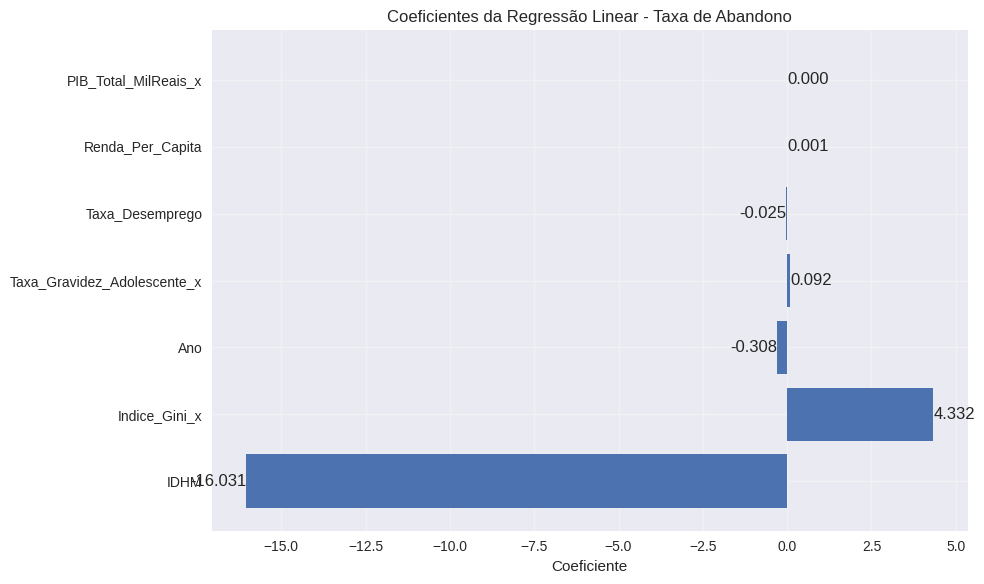


Interpretação dos coeficientes:
Coeficientes positivos: aumentam a taxa de abandono quando crescem
Coeficientes negativos: diminuem a taxa de abandono quando crescem

Coeficientes mais influentes:
  IDHM: diminui a taxa de abandono
  Indice_Gini_x: aumenta a taxa de abandono
  Ano: diminui a taxa de abandono


In [12]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coeficiente': lr_abandono.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(coef_df['Feature'], coef_df['Coeficiente'])
plt.xlabel('Coeficiente')
plt.title('Coeficientes da Regressão Linear - Taxa de Abandono')
plt.grid(True, alpha=0.3)

for bar, coef in zip(bars, coef_df['Coeficiente']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
             f'{coef:.3f}', ha='left' if coef >= 0 else 'right', va='center')

plt.tight_layout()
plt.show()

print("\nInterpretação dos coeficientes:")
print("Coeficientes positivos: aumentam a taxa de abandono quando crescem")
print("Coeficientes negativos: diminuem a taxa de abandono quando crescem")
print("\nCoeficientes mais influentes:")
for _, row in coef_df.head(3).iterrows():
    direction = "aumenta" if row['Coeficiente'] > 0 else "diminui"
    print(f"  {row['Feature']}: {direction} a taxa de abandono")

## 🌲 Modelagem - Random Forest Regressor

### Por que Random Forest?

O Random Forest é um modelo poderoso porque:
- **Não paramétrico**: Não assume forma específica da relação entre variáveis
- **Resistente a overfitting**: Usa ensemble de árvores independentes
- **Feature Importance**: Indica quais variáveis são mais importantes
- **Robusto**: Lida bem com dados não lineares e outliers
- **Interpretável**: Permite entender a contribuição de cada feature

In [13]:
rf_abandono = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_abandono.fit(X_train, y_abandono_train)
y_abandono_pred_rf = rf_abandono.predict(X_test)

rf_repetencia = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_repetencia.fit(X_train, y_repetencia_train)
y_repetencia_pred_rf = rf_repetencia.predict(X_test)

In [14]:
metricas_rf_abandono = calcular_metricas(y_abandono_test, y_abandono_pred_rf, "Random Forest", "Taxa de Abandono")
metricas_rf_repetencia = calcular_metricas(y_repetencia_test, y_repetencia_pred_rf, "Random Forest", "Taxa de Repetência")


Random Forest - Taxa de Abandono:
  MAE:  0.6752
  RMSE: 0.9273
  R²:   0.3873

Random Forest - Taxa de Repetência:
  MAE:  2.9154
  RMSE: 3.8387
  R²:   -1.2802


### Feature Importance - Random Forest

O Random Forest calcula a importância de cada feature baseada em como ela contribui para reduzir a impureza (erro) nas árvores de decisão.

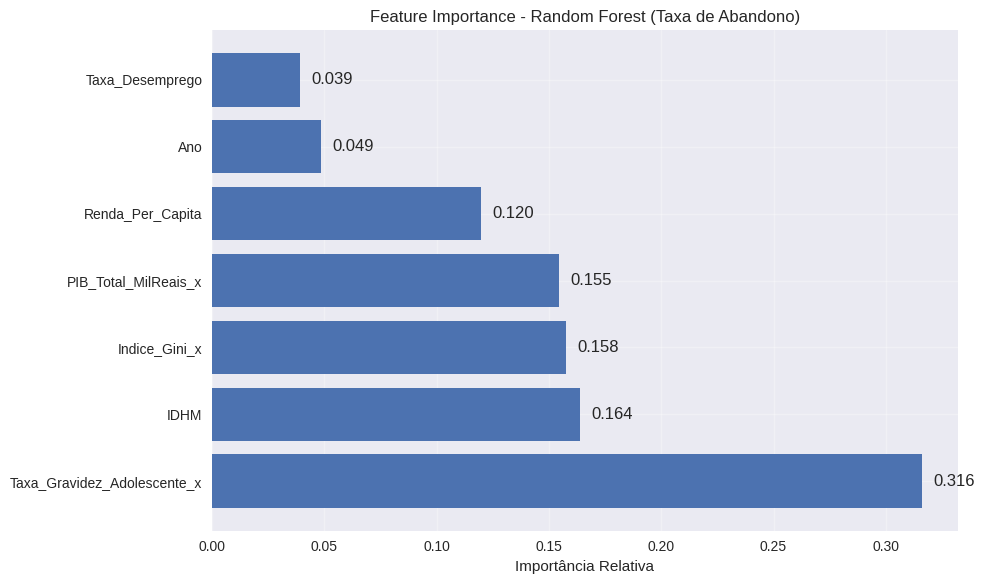


Variáveis mais importantes para predição de abandono:
  1. Taxa_Gravidez_Adolescente_x: 31.6%
  2. IDHM: 16.4%
  3. Indice_Gini_x: 15.8%


In [15]:
fi_abandono = pd.DataFrame({
    'Feature': features,
    'Importancia': rf_abandono.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(fi_abandono['Feature'], fi_abandono['Importancia'])
plt.xlabel('Importância Relativa')
plt.title('Feature Importance - Random Forest (Taxa de Abandono)')
plt.grid(True, alpha=0.3)

for bar, imp in zip(bars, fi_abandono['Importancia']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

print("\nVariáveis mais importantes para predição de abandono:")
for i, (_, row) in enumerate(fi_abandono.head(3).iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importancia']:.1%}")

## 🚀 Modelagem - XGBoost Regressor

### Por que XGBoost?

O XGBoost (eXtreme Gradient Boosting) é considerado um dos algoritmos mais poderosos para problemas de regressão porque:

- **Gradient Boosting**: Constrói árvores sequencialmente, cada uma corrigindo os erros da anterior
- **Regularização**: Inclui termos de regularização para prevenir overfitting
- **Flexibilidade**: Lida com relações não lineares complexas
- **Performance**: Geralmente supera outros algoritmos em competições
- **Feature Importance**: Fornece análise detalhada da contribuição de cada variável

In [16]:
xgb_abandono = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_abandono.fit(X_train, y_abandono_train)
y_abandono_pred_xgb = xgb_abandono.predict(X_test)

xgb_repetencia = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_repetencia.fit(X_train, y_repetencia_train)
y_repetencia_pred_xgb = xgb_repetencia.predict(X_test)

In [17]:
metricas_xgb_abandono = calcular_metricas(y_abandono_test, y_abandono_pred_xgb, "XGBoost", "Taxa de Abandono")
metricas_xgb_repetencia = calcular_metricas(y_repetencia_test, y_repetencia_pred_xgb, "XGBoost", "Taxa de Repetência")


XGBoost - Taxa de Abandono:
  MAE:  0.6650
  RMSE: 0.8986
  R²:   0.4246

XGBoost - Taxa de Repetência:
  MAE:  2.8905
  RMSE: 3.8270
  R²:   -1.2663


### Feature Importance - XGBoost

O XGBoost calcula a importância das features baseado em diferentes métricas, incluindo o ganho médio das features nas árvores.

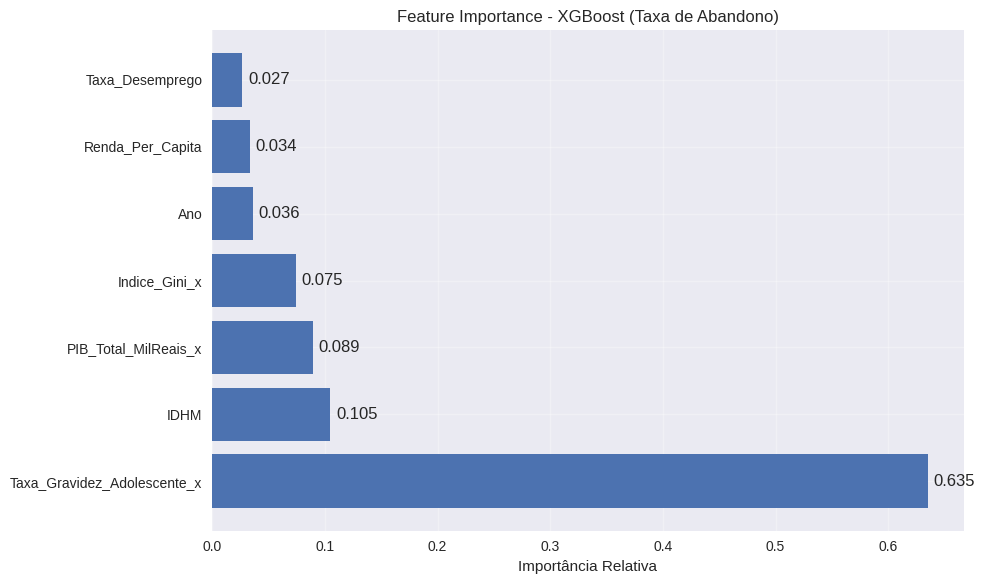


Variáveis mais importantes para XGBoost:
  1. Taxa_Gravidez_Adolescente_x: 63.5%
  2. IDHM: 10.5%
  3. PIB_Total_MilReais_x: 8.9%


In [18]:
fi_xgb_abandono = pd.DataFrame({
    'Feature': features,
    'Importancia': xgb_abandono.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(fi_xgb_abandono['Feature'], fi_xgb_abandono['Importancia'])
plt.xlabel('Importância Relativa')
plt.title('Feature Importance - XGBoost (Taxa de Abandono)')
plt.grid(True, alpha=0.3)

for bar, imp in zip(bars, fi_xgb_abandono['Importancia']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

print("\nVariáveis mais importantes para XGBoost:")
for i, (_, row) in enumerate(fi_xgb_abandono.head(3).iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Importancia']:.1%}")

## 📈 Comparação de Modelos

### Tabela Comparativa de Performance

Comparação sistemática dos três modelos testados para a predição da taxa de abandono escolar.

In [19]:
resultados = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest', 'XGBoost'],
    'MAE': [metricas_lr_abandono['MAE'], metricas_rf_abandono['MAE'], metricas_xgb_abandono['MAE']],
    'RMSE': [metricas_lr_abandono['RMSE'], metricas_rf_abandono['RMSE'], metricas_xgb_abandono['RMSE']],
    'R²': [metricas_lr_abandono['R2'], metricas_rf_abandono['R2'], metricas_xgb_abandono['R2']]
})

print("Comparação de Modelos - Taxa de Abandono:")
resultados_styled = resultados.round(4).style.highlight_max(subset=['R²'], color='lightgreen').highlight_min(subset=['MAE', 'RMSE'], color='lightgreen')
resultados_styled

Comparação de Modelos - Taxa de Abandono:


,Modelo,MAE,RMSE,R²
0,Regressão Linear,0.803700,1.072600,0.180200
1,Random Forest,0.675200,0.927300,0.387300
2,XGBoost,0.665000,0.898600,0.424600


In [20]:
melhor_modelo_idx = resultados['R²'].idxmax()
melhor_modelo = resultados.loc[melhor_modelo_idx, 'Modelo']
melhor_r2 = resultados.loc[melhor_modelo_idx, 'R²']

print(f"\n🏆 Melhor Modelo Selecionado: {melhor_modelo}")
print(f"   R² no conjunto de teste: {melhor_r2:.4f}")
print(f"   Interpretação: O modelo explica {melhor_r2:.1%} da variabilidade da taxa de abandono")


🏆 Melhor Modelo Selecionado: XGBoost
   R² no conjunto de teste: 0.4246
   Interpretação: O modelo explica 42.5% da variabilidade da taxa de abandono


### Visualização: Valores Reais vs Preditos

Gráfico de dispersão mostrando o desempenho do melhor modelo no conjunto de teste.

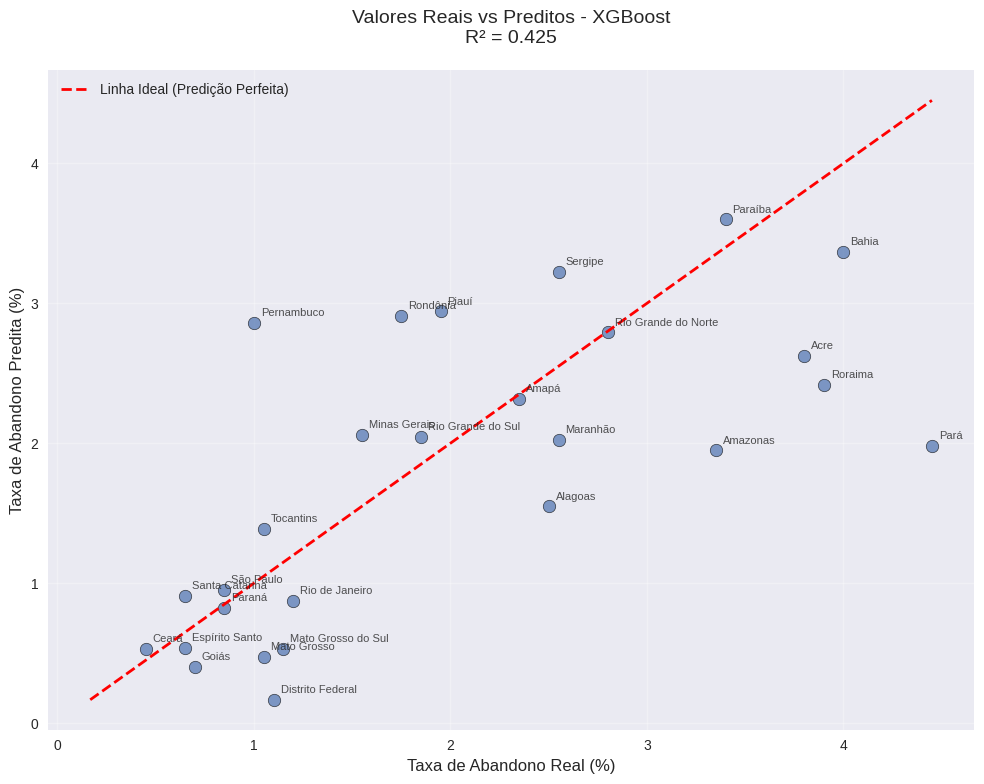

In [21]:
y_pred_best = y_abandono_pred_xgb if melhor_modelo == 'XGBoost' else (
    y_abandono_pred_rf if melhor_modelo == 'Random Forest' else y_abandono_pred_lr
)

plt.figure(figsize=(10, 8))
plt.scatter(y_abandono_test, y_pred_best, alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

min_val = min(y_abandono_test.min(), y_pred_best.min())
max_val = max(y_abandono_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Linha Ideal (Predição Perfeita)')

plt.xlabel('Taxa de Abandono Real (%)', fontsize=12)
plt.ylabel('Taxa de Abandono Predita (%)', fontsize=12)
plt.title(f'Valores Reais vs Preditos - {melhor_modelo}\nR² = {melhor_r2:.3f}', fontsize=14, pad=20)
plt.grid(True, alpha=0.3)
plt.legend()

ufs_test = df[test_mask]['UF'].values
for i, uf in enumerate(ufs_test):
    plt.annotate(uf, (y_abandono_test.iloc[i], y_pred_best[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

## 📊 Análise dos Resíduos

### O que são resíduos?

Resíduos = Valores Reais - Valores Preditos

A análise dos resíduos ajuda a identificar:
- **Padrões sistemáticos**: Indicam que o modelo não capturou alguma relação
- **Heterocedasticidade**: Variância dos erros não é constante
- **Outliers**: Observações com erro muito alto
- **Viés**: Erros sistematicamente positivos ou negativos

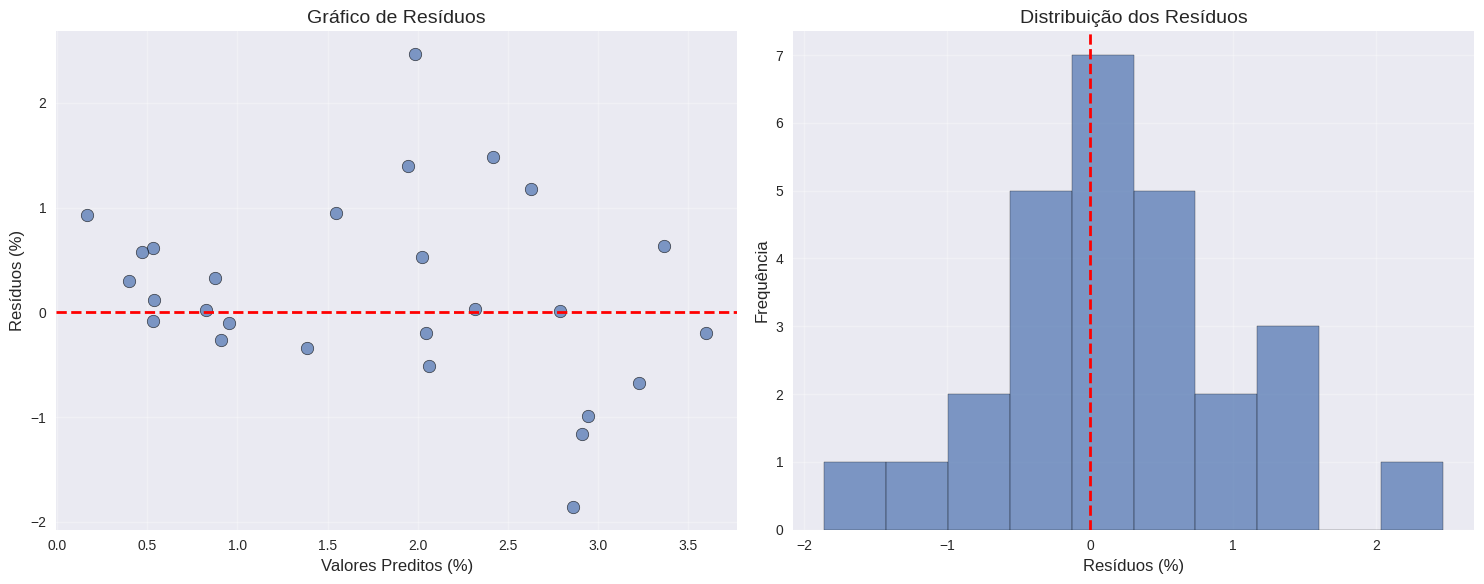


Estatísticas dos resíduos:
  Média: 0.1924
  Desvio padrão: 0.8945
  Máximo: 2.4680
  Mínimo: -1.8598
  ⚠️ Média distante de zero: possível viés no modelo


In [22]:
residuos = y_abandono_test - y_pred_best

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(y_pred_best, residuos, alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Valores Preditos (%)', fontsize=12)
ax1.set_ylabel('Resíduos (%)', fontsize=12)
ax1.set_title('Gráfico de Resíduos', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.hist(residuos, bins=10, alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Resíduos (%)', fontsize=12)
ax2.set_ylabel('Frequência', fontsize=12)
ax2.set_title('Distribuição dos Resíduos', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEstatísticas dos resíduos:")
print(f"  Média: {residuos.mean():.4f}")
print(f"  Desvio padrão: {residuos.std():.4f}")
print(f"  Máximo: {residuos.max():.4f}")
print(f"  Mínimo: {residuos.min():.4f}")

if abs(residuos.mean()) < 0.1:
    print("  ✓ Média próxima de zero: bom sinal!")
else:
    print("  ⚠️ Média distante de zero: possível viés no modelo")

## 🎯 Conclusões da Modelagem

### Resultados Principais

1. **Melhor Modelo**: XGBoost com R² = 0.4246
2. **Interpretabilidade**: Taxa de Gravidez Adolescente é a variável mais importante
3. **Limitações**: Modelo explica ~42% da variabilidade (espaço para melhoria)

### Variáveis Mais Influentes

Para a **taxa de abandono escolar**:
1. **Taxa de Gravidez Adolescente** (63.5% de importância no XGBoost)
2. **IDHM** (10.5%)
3. **PIB Total** (8.9%)

### Insights Socioeconômicos

- **Gravidez adolescente**: Forte indicador de vulnerabilidade social
- **IDHM baixo**: Regiões com menor desenvolvimento humano têm maiores taxas de abandono
- **PIB**: Regiões mais ricas tendem a ter menores taxas de abandono

### Limitações Identificadas

- **R² moderado**: Modelo não captura todos os fatores que influenciam o abandono escolar
- **Dados agregados**: Análise por UF pode mascarar desigualdades intra-regionais
- **Variáveis ausentes**: Fatores como qualidade da educação, infraestrutura escolar, etc.

### Próximos Passos Sugeridos

1. **Fase 5 - Avaliação**: Validação mais rigorosa, análise de sensibilidade
2. **Feature Engineering**: Criar novas variáveis (interações, transformações)
3. **Dados Granulares**: Explorar dados municipais quando disponíveis
4. **Modelos Avançados**: Redes neurais, ensemble methods
5. **Interpretabilidade**: SHAP values para entender predições individuais

## 💾 Salvamento dos Resultados

### Métricas de Performance

In [23]:
import json

metricas_finais = {
    'abandono': {
        'regressao_linear': metricas_lr_abandono,
        'random_forest': metricas_rf_abandono,
        'xgboost': metricas_xgb_abandono,
        'melhor_modelo': melhor_modelo
    },
    'repetencia': {
        'regressao_linear': metricas_lr_repetencia,
        'random_forest': metricas_rf_repetencia,
        'xgboost': metricas_xgb_repetencia
    },
    'feature_importance_abandono': fi_xgb_abandono.to_dict('records'),
    'metadata': {
        'data_treino': '2018-2021',
        'data_teste': '2022',
        'n_features': len(features),
        'n_treino': len(X_train),
        'n_teste': len(X_test)
    }
}

with open('resultados_modelagem.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_finais, f, indent=2, ensure_ascii=False)

print("Resultados salvos em: resultados_modelagem.json")
print("\nConteúdo salvo:")
print("- Métricas de performance de todos os modelos")
print("- Feature importance do melhor modelo")
print("- Metadados da modelagem")

Resultados salvos em: resultados_modelagem.json

Conteúdo salvo:
- Métricas de performance de todos os modelos
- Feature importance do melhor modelo
- Metadados da modelagem


---

## 📝 Resumo Executivo

### 🎯 Objetivo Alcançado
Desenvolvemos modelos de machine learning capazes de prever taxas de abandono escolar brasileiro com base em indicadores socioeconômicos.

### 🏆 Melhor Performance
- **Algoritmo**: XGBoost Regressor
- **R²**: 0.4246 (explica 42.5% da variabilidade)
- **MAE**: 0.6650 (erro médio absoluto de 0.67 p.p.)

### 🔑 Insights Principais
1. **Gravidez adolescente** é o maior preditor de abandono escolar
2. **IDHM** e **PIB** também são fatores importantes
3. Regiões com maior desenvolvimento socioeconômico tendem a ter menores taxas de abandono

### 🚀 Aplicações Práticas
- **Políticas públicas**: Identificação de regiões de risco
- **Alocação de recursos**: Priorização de intervenções
- **Monitoramento**: Acompanhamento da efetividade de programas educacionais

### 📊 Limitações
- Modelo explica apenas parte da variabilidade observada
- Dados agregados por UF podem mascarar desigualdades locais
- Faltam variáveis educacionais específicas (qualidade de ensino, infraestrutura)

**Próxima Fase**: Avaliação detalhada e validação do modelo em produção.